In [22]:
# NLP Project 5
# Social Media Comment Analysis

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')

from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
# Step 1: Collect Social Media Comments

comments = [
    "This product is amazing! I really love it.",
    "Worst customer service ever.",
    "The quality is excellent.",
    "Very disappointed with the product.",
    "Fast delivery and good packaging.",
    "Waste of money.",
    "I am extremely happy with this purchase.",
    "Not worth buying.",
    "Fantastic experience, highly recommended.",
    "Terrible product and poor quality.",
    "Loved the design and performance.",
    "Customer support was very helpful.",
    "Bad experience.",
    "Excellent value for money.",
    "The product stopped working after one day."
]

df = pd.DataFrame(comments, columns=["Comment"])

print(df.head())


                                      Comment
0  This product is amazing! I really love it.
1                Worst customer service ever.
2                   The quality is excellent.
3         Very disappointed with the product.
4           Fast delivery and good packaging.


In [24]:
# Step 2: Text Cleaning

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

print(df.head())


                                      Comment               Cleaned_Comment
0  This product is amazing! I really love it.   product amazing really love
1                Worst customer service ever.   worst customer service ever
2                   The quality is excellent.             quality excellent
3         Very disappointed with the product.          disappointed product
4           Fast delivery and good packaging.  fast delivery good packaging


In [25]:
# Step 3: Sentiment Analysis

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Comment"].apply(get_sentiment)

print("\nSentiment Results:")
print(df[["Comment", "Sentiment"]])



Sentiment Results:
                                       Comment Sentiment
0   This product is amazing! I really love it.  Positive
1                 Worst customer service ever.  Negative
2                    The quality is excellent.  Positive
3          Very disappointed with the product.  Negative
4            Fast delivery and good packaging.  Positive
5                              Waste of money.  Negative
6     I am extremely happy with this purchase.  Positive
7                            Not worth buying.  Positive
8    Fantastic experience, highly recommended.  Positive
9           Terrible product and poor quality.  Negative
10           Loved the design and performance.  Positive
11          Customer support was very helpful.   Neutral
12                             Bad experience.  Negative
13                  Excellent value for money.  Positive
14  The product stopped working after one day.   Neutral


In [26]:
# Step 4: Identify Trending Topics

vectorizer = CountVectorizer(max_features=10)

X = vectorizer.fit_transform(df["Cleaned_Comment"])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

topics = pd.DataFrame({
    "Word": words,
    "Frequency": counts
}).sort_values(by="Frequency", ascending=False)

print("\nTrending Topics:")
print(topics)



Trending Topics:
           Word  Frequency
8       product          4
1      customer          2
9       quality          2
5     excellent          2
6    experience          2
7         money          2
0       amazing          1
4  disappointed          1
2           day          1
3        design          1


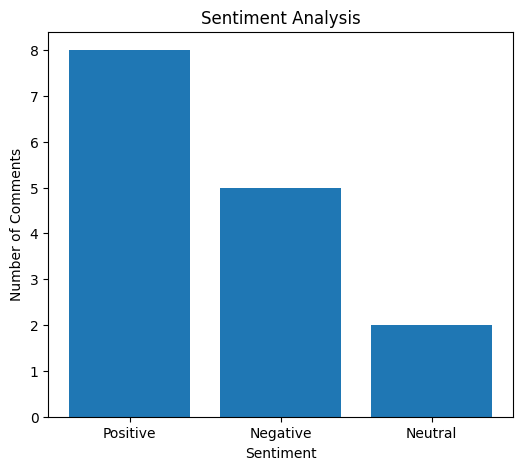

In [27]:
# Step 5A: Sentiment Visualization

sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


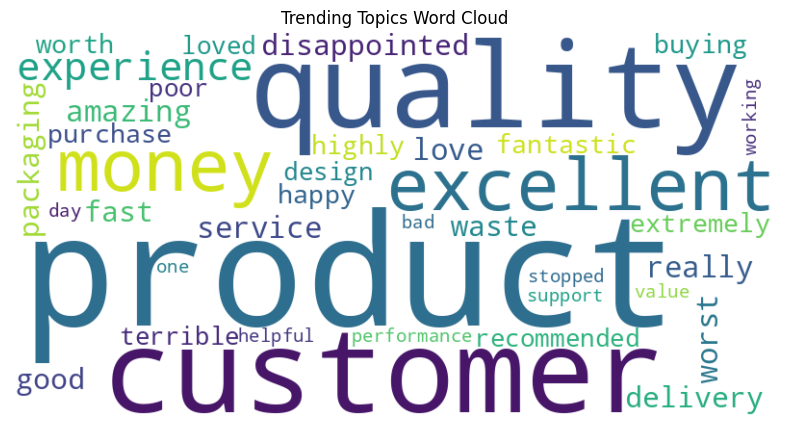

In [28]:
# Step 5B: Word Cloud

text = " ".join(df["Cleaned_Comment"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Topics Word Cloud")
plt.show()


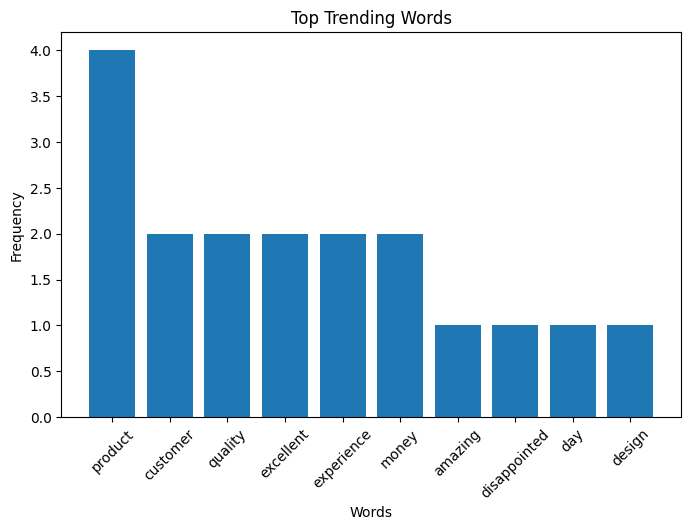

In [29]:
# Step 5C: Top Trending Words

plt.figure(figsize=(8,5))
plt.bar(topics["Word"], topics["Frequency"])
plt.xticks(rotation=45)
plt.title("Top Trending Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [30]:
# Final Dataset

print("\nFinal Dataset")
print(df)


Final Dataset
                                       Comment  \
0   This product is amazing! I really love it.   
1                 Worst customer service ever.   
2                    The quality is excellent.   
3          Very disappointed with the product.   
4            Fast delivery and good packaging.   
5                              Waste of money.   
6     I am extremely happy with this purchase.   
7                            Not worth buying.   
8    Fantastic experience, highly recommended.   
9           Terrible product and poor quality.   
10           Loved the design and performance.   
11          Customer support was very helpful.   
12                             Bad experience.   
13                  Excellent value for money.   
14  The product stopped working after one day.   

                            Cleaned_Comment Sentiment  
0               product amazing really love  Positive  
1               worst customer service ever  Negative  
2               